In [1]:
import pickle, sys
import pandas as pd
sys.path.append('..')

from models.path_finder import build_mood_graph

df = pd.read_parquet('../data/tracks.parquet')
G  = build_mood_graph(df, k=10)

with open('../models/mood_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')

Building mood graph for 999 Bollywood tracks (k=10)...
Graph: 999 nodes, 9990 edges
Nodes: 999
Edges: 9990


In [2]:
sad = df[df.valence < 0.15].head(3)
print('Very sad tracks:')
print(sad[['name', 'artist', 'valence', 'energy']].to_string())
print()

test_id = sad.iloc[0]['id']
nbrs    = list(G.neighbors(test_id))[:5]
print(f"Neighbours of: {G.nodes[test_id]['name']}")
for n in nbrs:
    a = G.nodes[n]
    print(f"  {a['name'][:40]:40s} val={a['valence']:.2f} nrg={a['energy']:.2f}")

Very sad tracks:
                                     name                    artist  valence  energy
76           Woh Lamhe Woh Baatein - LoFi  Poorvesh Dave;Kuxh Beats   0.1490   0.516
97   Get You The Moon X Agar Tum Saath Ho                Pranish VP   0.1300   0.372
153                       Huzur (Reprise)            Rusha & Blizza   0.0399   0.475

Neighbours of: Woh Lamhe Woh Baatein - LoFi
  Ami Je Tomar Tandav (Film Version)       val=0.17 nrg=0.53
  Soulful Love Lofi (Slowed & Reverb)      val=0.17 nrg=0.50
  Buniyaad                                 val=0.15 nrg=0.48
  Hoye Ishq Na                             val=0.14 nrg=0.55
  Hoye Ishq Na (From "Tadap")              val=0.14 nrg=0.55


Udaas -> Khushi journey:
  1. Shor                                   val=0.16 nrg=0.20
  2. Aararo                                 val=0.19 nrg=0.22
  3. Lost Boy                               val=0.22 nrg=0.26
  4. Pal Pal Dil Ke Paas - Unwind Instrumen val=0.24 nrg=0.28
  5. Muskurane - Lofi Flip                  val=0.26 nrg=0.31
  6. Kahaani                                val=0.27 nrg=0.33
  7. What Is Love                           val=0.30 nrg=0.36
  8. Pal Pal Dil Ke Paas - Lofi             val=0.32 nrg=0.38


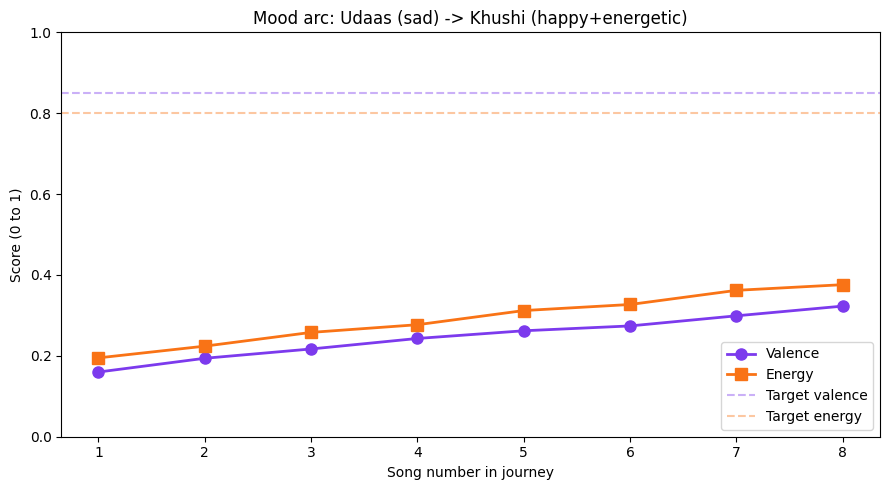

Saved to data/mood_arc.png


In [3]:
import matplotlib.pyplot as plt
from models.path_finder import find_journey

journey = find_journey(G,
    start_valence=0.15, start_energy=0.20,
    target_valence=0.85, target_energy=0.80,
    n_songs=8
)

print('Udaas -> Khushi journey:')
for s in journey:
    print(f"  {s['position']+1}. {s['name'][:38]:38s}"
          f" val={s['valence']:.2f} nrg={s['energy']:.2f}")

steps    = [s['position'] + 1 for s in journey]
valences = [s['valence']      for s in journey]
energies = [s['energy']       for s in journey]

plt.figure(figsize=(9, 5))
plt.plot(steps, valences, 'o-', color='#7C3AED',
         label='Valence', linewidth=2, markersize=8)
plt.plot(steps, energies, 's-', color='#F97316',
         label='Energy',  linewidth=2, markersize=8)
plt.axhline(0.85, color='#7C3AED', linestyle='--', alpha=0.4, label='Target valence')
plt.axhline(0.80, color='#F97316', linestyle='--', alpha=0.4, label='Target energy')
plt.xlabel('Song number in journey')
plt.ylabel('Score (0 to 1)')
plt.title('Mood arc: Udaas (sad) -> Khushi (happy+energetic)')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../data/mood_arc.png', dpi=150)
plt.show()
print('Saved to data/mood_arc.png')